Ten skrypt tworzy interaktywnego asystenta planowania podróży przy użyciu bibliotek LangGraph i OpenAI. Definiuje on graf przepływu pracy, który najpierw pyta użytkownika o miasto docelowe, a następnie o jego zainteresowania. Po zebraniu tych informacji, skrypt używa modelu językowego OpenAI do wygenerowania spersonalizowanego planu jednodniowej wycieczki i wyświetla go użytkownikowi.

# Setup

In [ ]:
!uv pip install langgraph langchain langchain-openai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.3/423.3 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 kB 10.1 MB/s eta 0:00:00


In [ ]:
import os
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph, END
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display, Image
from google.colab import userdata


In [ ]:
class CFG:
    model = "gpt-4o-mini"
    temp = 0.3


os.environ["OPENAI_API_KEY"] = userdata.get("openaivision")

# Agent

In [ ]:
llm = ChatOpenAI(model=CFG.model, temperature=CFG.temp)


itinerary_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful travel assistant. Create a day trip itinerary for {city} based on the user's interests: {interests}. Provide a brief, bulleted itinerary.",
        ),
        ("human", "Create an itinerary for my day trip."),
    ]
)

In [ ]:
class PlannerState(TypedDict):
    messages: Annotated[
        List[HumanMessage | AIMessage], "The messages in the conversation"
    ]
    city: str
    interests: List[str]
    itinerary: str

### Czym jest `PlannerState`?

`PlannerState` definiuje strukturę danych, która będzie przechowywać aktualny stan naszego systemu planowania podróży. Jest to forma "pamięci" aplikacji - zawiera wszystkie informacje, które system zebrał i przetworzył do danego momentu, oraz które będą potrzebne do wykonania kolejnych kroków.

### Składniki stanu:

1. **`messages: Annotated[List[HumanMessage | AIMessage], "The messages in the conversation"]`**

   Ta linia definiuje pole `messages`, które przechowuje historię konwersacji jako listę obiektów typu `HumanMessage` lub `AIMessage`. Użycie `Annotated` dodaje opis wyjaśniający znaczenie tego pola: "Wiadomości w konwersacji".
   
   Operator `|` (pipe) między `HumanMessage` i `AIMessage` oznacza, że każdy element listy może być albo wiadomością od użytkownika, albo od AI. Jest to przykład użycia tzw. "union types" w Pythonie.

2. **`city: str`**

   Pole przechowujące nazwę miasta, dla którego tworzony jest plan podróży. Określono, że wartość musi być stringiem.

3. **`interests: List[str]`**

   Lista zainteresowań użytkownika, które będą wpływać na generowany plan podróży. Każde zainteresowanie jest reprezentowane jako string.

4. **`itinerary: str`**

   Pole przechowujące wygenerowany plan podróży jako tekst. Po zakończeniu działania grafu to pole będzie zawierać finalny rezultat pracy systemu.

### Głębsze zrozumienie:

`TypedDict` to stosunkowo nowa funkcja Pythona, która pozwala na definiowanie słowników z określonymi typami wartości dla konkretnych kluczy. W przeciwieństwie do zwykłych słowników, które mogą mieć dowolne klucze i wartości, `TypedDict` narzuca konkretną strukturę, co jest szczególnie cenne w dużych i skomplikowanych aplikacjach.

W kontekście LangGraph, ta klasa jest fundamentalna z kilku powodów:

1. **Przepływ danych:** W aplikacji opartej na grafie stanów, stan musi być przekazywany między różnymi węzłami (funkcjami), a każdy węzeł może go modyfikować. `TypedDict` zapewnia spójną strukturę, dzięki czemu każdy węzeł "wie", czego oczekiwać.

2. **Bezpieczeństwo typów:** Określenie typów poszczególnych pól pomaga uniknąć błędów podczas rozwoju aplikacji. System sprawdzania typów w Pythonie (lub zewnętrzne narzędzia jak mypy) może wykrywać potencjalne problemy, zanim kod zostanie uruchomiony.

3. **Dokumentacja:** Sama definicja klasy stanowi formę dokumentacji, informującą innych programistów, jakie dane są przechowywane i jaki format mają.

### Praktyczne zastosowanie:

W praktycznym użyciu, graf stanów będzie manipulował tym stanem w następujący sposób:

1. **Inicjalizacja:** Na początku stan zostanie zainicjowany z pustą listą wiadomości i prawdopodobnie pustymi wartościami dla innych pól.

2. **Zbieranie informacji:** Węzły grafu będą dodawać wiadomości do listy `messages`, ustawiać wartości `city` i `interests` na podstawie interakcji z użytkownikiem.

3. **Generowanie planu:** Po zebraniu wszystkich potrzebnych informacji, specjalny węzeł wykorzysta model językowy, by wypełnić pole `itinerary` wygenerowanym planem podróży.

4. **Prezentacja wyników:** Finalnie, system przekaże użytkownikowi zawartość pola `itinerary` jako wynik działania.

Ten rodzaj strukturyzacji danych jest typowym przykładem, jak nowoczesne aplikacje AI zarządzają stanem i przepływem informacji, łącząc typowanie Pythona z możliwościami dużych modeli językowych i grafów decyzyjnych.

In [ ]:
def input_city(state: PlannerState) -> PlannerState:
    print("Please enter the city you want to visit for your day trip:")
    user_message = input("Your input: ")
    return {
        **state,
        "city": user_message,
        "messages": state["messages"] + [HumanMessage(content=user_message)],
    }

Funkcja `input_city` to jeden z węzłów w grafie stanów aplikacji planującej podróże. Jest to funkcja interaktywna, która pobiera od użytkownika nazwę miasta i aktualizuje stan aplikacji. Przeanalizujmy ją krok po kroku, aby zrozumieć jej działanie i rolę w większym systemie.

In [ ]:
def input_interests(state: PlannerState) -> PlannerState:
    print(
        f"Please enter your interests for the trip to {state['city']} (comma-separated):"
    )
    user_message = input("Your input: ")
    return {
        **state,
        "interests": [interest.strip() for interest in user_message.split(",")],
        "messages": state["messages"] + [HumanMessage(content=user_message)],
    }

Funkcja `input_interests` stanowi drugi kluczowy węzeł w grafie stanów naszej aplikacji planowania podróży. Przyjrzyjmy się, jak działa i jaka jest jej rola w całościowym procesie planowania.

In [ ]:
def create_itinerary(state: PlannerState) -> PlannerState:
    print(
        f"Creating an itinerary for {state['city']} based on interests: {', '.join(state['interests'])}..."
    )
    response = llm.invoke(
        itinerary_prompt.format_messages(
            city=state["city"], interests=", ".join(state["interests"])
        )
    )
    print("\nFinal Itinerary:")
    print(response.content)
    return {
        **state,
        "messages": state["messages"] + [AIMessage(content=response.content)],
        "itinerary": response.content,
    }

Funkcja `create_itinerary` stanowi kulminacyjny punkt w naszym systemie planowania podróży. W tej funkcji wykorzystujemy model językowy, aby wygenerować spersonalizowany plan podróży na podstawie wcześniej zebranych informacji. Przeanalizujmy dokładnie, jak działa ta funkcja i jaką rolę pełni w całej aplikacji.

# Graf

In [ ]:
workflow = StateGraph(PlannerState)

workflow.set_entry_point("input_city")

workflow.add_node("input_city", input_city)
workflow.add_node("input_interests", input_interests)
workflow.add_node("create_itinerary", create_itinerary)

workflow.add_edge("input_city", "input_interests")
workflow.add_edge("input_interests", "create_itinerary")
workflow.add_edge("create_itinerary", END)

app = workflow.compile()

### Czym jest graf stanów w praktyce?

Graf stanów to wzorzec projektowy, który reprezentuje przepływ aplikacji jako sieć węzłów (funkcji) połączonych krawędziami (przejściami). W kontekście aplikacji AI, jest to szczególnie przydatne, ponieważ:

1. **Modularność** - Całą logikę aplikacji można podzielić na małe, łatwe do zrozumienia i przetestowania funkcje.
2. **Wizualizacja** - Przepływ aplikacji można łatwo zwizualizować i komunikować (np. za pomocą diagramów).
3. **Elastyczność** - Zmiany w przepływie wymagają tylko modyfikacji krawędzi grafu, bez konieczności zmiany poszczególnych funkcji.
4. **Śledzenie stanu** - Stan aplikacji jest jawnie przekazywany między węzłami, co ułatwia zrozumienie i debugowanie.

W naszym przypadku, utworzony graf stanów reprezentuje prosty proces zbierania informacji i generowania planu podróży. Zmienny stan (informacje o mieście, zainteresowaniach i wygenerowany plan) przepływa przez graf, będąc modyfikowanym przez kolejne węzły.

W bardziej zaawansowanych scenariuszach, graf mógłby zawierać węzły podejmujące decyzje (np. sprawdzające, czy zebrane informacje są wystarczające), węzły obsługujące błędy czy węzły komunikujące się z zewnętrznymi usługami.

Finalnie, skompilowany obiekt `app` reprezentuje naszą gotową aplikację, którą można uruchomić, aby przeprowadzić użytkownika przez cały proces planowania podróży. W typowym scenariuszu, wywołalibyśmy `app.invoke(initial_state)` z początkowym stanem, aby rozpocząć proces.

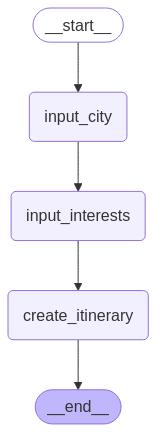

In [ ]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [ ]:
def run_travel_planner(user_request: str):
    print(f"Initial Request: {user_request}\n")
    state = {
        "messages": [HumanMessage(content=user_request)],
        "city": "",
        "interests": [],
        "itinerary": "",
    }

    for output in app.stream(state):
        pass  # The nodes themselves now handle all printing

Funkcja `run_travel_planner` stanowi swoisty interfejs użytkownika dla naszego systemu planowania podróży, umożliwiający jego uruchomienie z początkowym zapytaniem. Ta funkcja wiąże wszystkie elementy, które dotychczas omówiliśmy, w kompletny i użyteczny system.

### Praktyczne zastosowanie i potencjalne rozszerzenia

Funkcja `run_travel_planner` stanowi prosty interfejs dla naszej aplikacji, umożliwiający jej uruchomienie z początkowym zapytaniem. W rzeczywistej aplikacji moglibyśmy dodać więcej funkcjonalności, takich jak:

1. Zapisywanie wygenerowanych planów podróży do pliku
2. Umożliwienie użytkownikowi modyfikacji planu po jego wygenerowaniu
3. Dodanie opcji dzielenia się planem przez e-mail lub media społecznościowe
4. Implementacja pamięci, która przechowywałaby preferencje użytkownika między sesjami

Warto również zauważyć, że obecna implementacja zakłada bezproblemowe działanie każdego kroku. W rzeczywistej aplikacji należałoby dodać obsługę błędów i nieoczekiwanych sytuacji, takich jak problemy z połączeniem z API modelu językowego czy nieoczekiwane formaty danych wejściowych.

Podsumowując, funkcja `run_travel_planner` jest ostatnim elementem układanki, który łączy wszystkie komponenty naszego systemu planowania podróży w działającą całość, umożliwiając użytkownikowi uzyskanie spersonalizowanego planu podróży poprzez prostą interakcję z systemem.

# Test

In [ ]:
user_request = "I want to plan a day trip."
run_travel_planner(user_request)

Initial Request: I want to plan a day trip.

Please enter the city you want to visit for your day trip:
Your input: Lublin
Please enter your interests for the trip to Lublin (comma-separated):
Your input: Food and culture
Creating an itinerary for Lublin based on interests: Food and culture...

Final Itinerary:
### Day Trip Itinerary for Lublin: Focus on Food and Culture

**Morning:**
- **8:30 AM - Breakfast at Café Grodzka**  
  - Enjoy traditional Polish breakfast items, such as scrambled eggs with smoked salmon and freshly baked bread.
  
- **9:30 AM - Explore the Old Town**  
  - Take a leisurely stroll through the charming cobblestone streets and see key landmarks such as the Lublin Castle and the Kraków Gate.

**Mid-Morning:**
- **11:00 AM - Visit the Majdanek Concentration Camp Memorial**  
  - Reflect on history at this poignant site, which preserves the memory of victims from World War II. 

**Lunch:**
- **1:00 PM - Lunch at Chata**  
  - Experience traditional Polish cuisine.